<a href="https://colab.research.google.com/github/samimhossainmondal6003-dotcom/AI_ML_LAB/blob/main/problem2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


        WATER JUG PROBLEM - BFS SOLUTION
Step 0: Initial State      State = (0, 0)
Step 1: Fill Jug B         State = (0, 3)
Step 2: Pour B → A         State = (3, 0)
Step 3: Fill Jug B         State = (3, 3)
Step 4: Pour B → A         State = (4, 2)
Minimum number of operations = 4
Goal state = (4, 2)


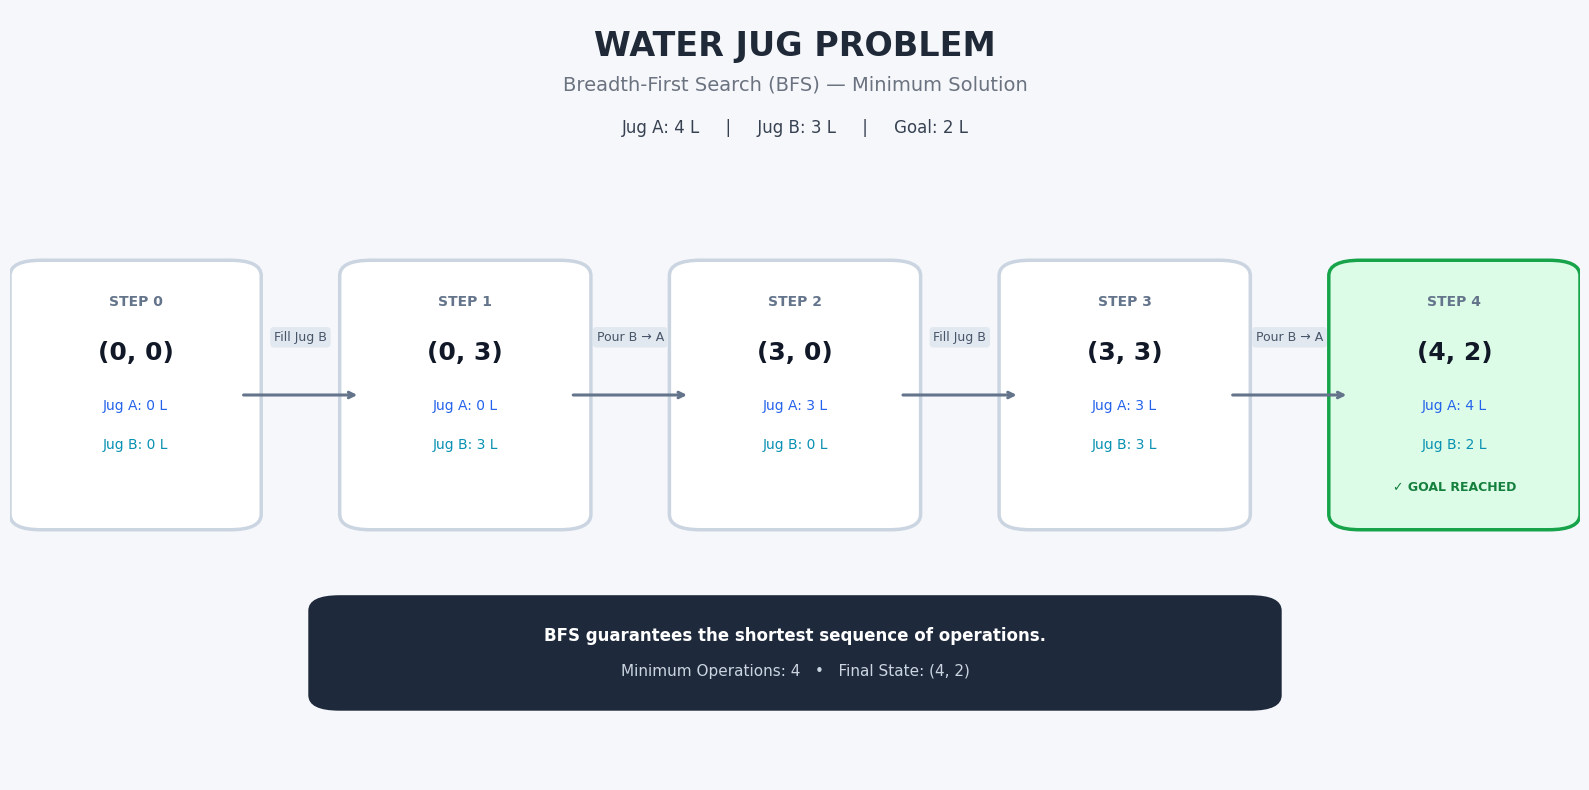

In [5]:
from collections import deque
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ============================================================
# WATER JUG PROBLEM - BFS
# Jug A = 4 Litres
# Jug B = 3 Litres
# Goal = 2 Litres in either jug
# ============================================================

CAP_A = 4
CAP_B = 3

initial_state = (0, 0)


# ------------------------------------------------------------
# Check goal
# ------------------------------------------------------------
def is_goal(state):
    return state[0] == 2 or state[1] == 2


# ------------------------------------------------------------
# Generate possible states
# ------------------------------------------------------------
def get_next_states(state):

    a, b = state
    states = []

    # Fill Jug A
    if a < CAP_A:
        states.append(((CAP_A, b), "Fill Jug A"))

    # Fill Jug B
    if b < CAP_B:
        states.append(((a, CAP_B), "Fill Jug B"))

    # Empty Jug A
    if a > 0:
        states.append(((0, b), "Empty Jug A"))

    # Empty Jug B
    if b > 0:
        states.append(((a, 0), "Empty Jug B"))

    # Pour A -> B
    if a > 0 and b < CAP_B:
        amount = min(a, CAP_B - b)

        states.append(
            ((a - amount, b + amount),
             "Pour A → B")
        )

    # Pour B -> A
    if b > 0 and a < CAP_A:
        amount = min(b, CAP_A - a)

        states.append(
            ((a + amount, b - amount),
             "Pour B → A")
        )

    return states


# ------------------------------------------------------------
# BFS
# ------------------------------------------------------------
def bfs():

    queue = deque([initial_state])

    visited = {initial_state}

    parent = {
        initial_state: None
    }

    action = {
        initial_state: "Initial State"
    }

    while queue:

        current = queue.popleft()

        if is_goal(current):

            path = []

            while current is not None:
                path.append(
                    (current, action[current])
                )

                current = parent[current]

            path.reverse()

            return path

        for next_state, operation in get_next_states(current):

            if next_state not in visited:

                visited.add(next_state)

                parent[next_state] = current

                action[next_state] = operation

                queue.append(next_state)

    return None


# ============================================================
# FIND SOLUTION
# ============================================================

solution = bfs()


# ============================================================
# PRINT SOLUTION
# ============================================================

print("\n" + "=" * 55)
print("        WATER JUG PROBLEM - BFS SOLUTION")
print("=" * 55)

for i, (state, operation) in enumerate(solution):

    print(
        f"Step {i}: "
        f"{operation:<18} "
        f"State = {state}"
    )

print("=" * 55)

print(
    f"Minimum number of operations = {len(solution) - 1}"
)

print(
    f"Goal state = {solution[-1][0]}"
)

print("=" * 55)


# ============================================================
# BEAUTIFUL VISUALIZATION
# ============================================================

fig, ax = plt.subplots(
    figsize=(16, 8)
)

fig.patch.set_facecolor("#F5F7FA")
ax.set_facecolor("#F5F7FA")

ax.axis("off")


# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

ax.text(
    0.5,
    0.94,
    "WATER JUG PROBLEM",
    transform=ax.transAxes,
    ha="center",
    fontsize=24,
    fontweight="bold",
    color="#1F2937"
)

ax.text(
    0.5,
    0.895,
    "Breadth-First Search (BFS) — Minimum Solution",
    transform=ax.transAxes,
    ha="center",
    fontsize=14,
    color="#6B7280"
)


# ------------------------------------------------------------
# Number of steps
# ------------------------------------------------------------

ax.text(
    0.5,
    0.84,
    f"Jug A: 4 L     |     Jug B: 3 L     |     Goal: 2 L",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    color="#374151"
)


# ------------------------------------------------------------
# Positions of states
# ------------------------------------------------------------

n = len(solution)

x_positions = [
    0.08 + i * (0.84 / (n - 1))
    for i in range(n)
]

y_position = 0.50


# ------------------------------------------------------------
# Draw states
# ------------------------------------------------------------

for i, ((a, b), operation) in enumerate(solution):

    x = x_positions[i]

    # Is this goal state?
    goal = is_goal((a, b))

    # --------------------------------------------------------
    # State box
    # --------------------------------------------------------

    box_color = "#DCFCE7" if goal else "#FFFFFF"

    border_color = "#16A34A" if goal else "#CBD5E1"

    box = FancyBboxPatch(
        (
            x - 0.065,
            y_position - 0.16
        ),
        0.13,
        0.32,
        boxstyle="round,pad=0.015,rounding_size=0.02",
        facecolor=box_color,
        edgecolor=border_color,
        linewidth=2.5,
        transform=ax.transAxes
    )

    ax.add_patch(box)


    # --------------------------------------------------------
    # Step number
    # --------------------------------------------------------

    ax.text(
        x,
        y_position + 0.115,
        f"STEP {i}",
        transform=ax.transAxes,
        ha="center",
        fontsize=10,
        fontweight="bold",
        color="#64748B"
    )


    # --------------------------------------------------------
    # State
    # --------------------------------------------------------

    ax.text(
        x,
        y_position + 0.045,
        f"({a}, {b})",
        transform=ax.transAxes,
        ha="center",
        fontsize=18,
        fontweight="bold",
        color="#111827"
    )


    # --------------------------------------------------------
    # Jug amounts
    # --------------------------------------------------------

    ax.text(
        x,
        y_position - 0.02,
        f"Jug A: {a} L",
        transform=ax.transAxes,
        ha="center",
        fontsize=10,
        color="#2563EB"
    )

    ax.text(
        x,
        y_position - 0.07,
        f"Jug B: {b} L",
        transform=ax.transAxes,
        ha="center",
        fontsize=10,
        color="#0891B2"
    )


    # --------------------------------------------------------
    # Goal label
    # --------------------------------------------------------

    if goal:

        ax.text(
            x,
            y_position - 0.125,
            "✓ GOAL REACHED",
            transform=ax.transAxes,
            ha="center",
            fontsize=9,
            fontweight="bold",
            color="#15803D"
        )


# ============================================================
# DRAW ARROWS BETWEEN STATES
# ============================================================

for i in range(len(solution) - 1):

    x1 = x_positions[i] + 0.067
    x2 = x_positions[i + 1] - 0.067

    ax.annotate(
        "",
        xy=(x2, y_position),
        xytext=(x1, y_position),
        xycoords=ax.transAxes,
        arrowprops=dict(
            arrowstyle="->",
            color="#64748B",
            linewidth=2.2
        )
    )

    # Operation label
    operation = solution[i + 1][1]

    ax.text(
        (x1 + x2) / 2,
        y_position + 0.075,
        operation,
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=9,
        color="#475569",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="#E2E8F0",
            edgecolor="none"
        )
    )


# ============================================================
# BOTTOM INFORMATION PANEL
# ============================================================

panel = FancyBboxPatch(
    (0.20, 0.10),
    0.60,
    0.13,
    boxstyle="round,pad=0.01,rounding_size=0.02",
    facecolor="#1E293B",
    edgecolor="none",
    transform=ax.transAxes
)

ax.add_patch(panel)


ax.text(
    0.5,
    0.18,
    "BFS guarantees the shortest sequence of operations.",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    fontweight="bold",
    color="white"
)

ax.text(
    0.5,
    0.135,
    f"Minimum Operations: {len(solution) - 1}   •   "
    f"Final State: {solution[-1][0]}",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="#CBD5E1"
)


# ============================================================
# SHOW
# ============================================================

plt.tight_layout()
plt.show()
